# # **IBL - Anatomical Localization of Widefield Imaging Data** with `ndx-anatomical-localization`

This notebook shows how to stream and visualise the atlas-registration and
anatomical-coordinate data from [DANDI:001713](https://dandiarchive.org/dandiset/001713)
(embargoed) using the
[`ndx-anatomical-localization`](https://github.com/catalystneuro/ndx-anatomical-localization)
NWB extension.

## Extension overview

| Type | Where | Description |
|---|---|---|
| `AtlasRegistration` | `nwbfile.lab_meta_data["atlas_registration"]` | Images + affine transform + landmarks |
| `Localization` | `nwbfile.lab_meta_data["localization"]` | Per-pixel coordinates + region masks + coordinate tables |
| `AffineTransformation` | inside `AtlasRegistration` | 3×3 homogeneous matrix: source px → registered px |
| `Landmarks` | inside `AtlasRegistration` | Manually placed control-point table |
| `AnatomicalCoordinatesImage` | `localization.anatomical_coordinates_images` | Per-pixel `(x, y, z)` + region acronym arrays |
| `AnatomicalCoordinatesTable` | `localization.anatomical_coordinates_tables` | 3-D coordinates for discrete objects (landmarks) |

## Contents

1. [Setup and Data Access](#setup)
2. [Atlas Registration](#atlas-registration)
   - [Summary images](#images)
   - [Affine Transformation](#affine)
   - [Landmarks table](#landmarks)
3. [Anatomical Coordinates Image](#aci)
4. [Anatomical Coordinates Tables](#act)

---

## 1. Setup and Data Access <a id="setup"></a>

In [1]:
# IMPORTANT: import ndx_anatomical_localization BEFORE read_nwb.
# This executes all @register_class decorators so PyNWB maps
# custom types (e.g. BrainRegionMasks) to the correct Python classes.
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import ndx_anatomical_localization  # noqa: F401
import numpy as np
from matplotlib.colors import ListedColormap
from skimage.transform import SimilarityTransform

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [2]:
from ibl_widefield_to_nwb.widefield2025.tutorials.load_nwb_utils import *

dandiset_id = "001713"  # Embargoed IBL widefield dandiset
subject_id = "CSK-im-009"  # Example CSK subject — update as needed
session_id = "2864dca1-38d8-464c-9777-f6fdfd5e63b5"  # Example session EID

# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id, description="raw")
else:
    # TODO Specify your local directory path
    local_directory = f"E:/IBL-widefield-nwbfiles/full/"
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id, description="raw")

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 The neural representations of prior information about the state of the world are poorly understood. Here, to investigate them, we examined brain-wide Neuropixels recordings and widefield calcium imaging collected by the International Brain Laboratory. Mice were trained to indicate the location of a visual grating stimulus, which appeared on the left or right with a prior probability alternating between 0.2 and 0.8 in blocks of variable length. We found that mice estimate this prior probability and thereby improve their decision accuracy. Furthermore, we report that this subjective prior is encoded in at least 20% to 30% of brain regions, notably, that span all levels of processing, from early sensory areas (the lateral geniculate nucleus and primary visual cortex) to motor regions (secondary and primary motor cortex and gigantocellular reticular nucleus) and high-level cortical regions (the dorsal anterior cingulate area and ventrola

---

## 2. Atlas Registration <a id="atlas-registration"></a>

`AtlasRegistration` lives at `nwbfile.lab_meta_data["atlas_registration"]` and groups
all outputs of the atlas-registration pipeline:

| Field | Type | Description |
|---|---|---|
| `source_image` | `GrayscaleImage` | Mean FOV in camera space |
| `registered_image` | `GrayscaleImage` | FOV after affine warp to atlas space |
| `atlas_projection` | `GrayscaleImage` | 2-D Allen CCF dorsal-cortex reference |
| `affine_transformation` | `AffineTransformation` | 3×3 homogeneous matrix |
| `landmarks` | `Landmarks` | Manually placed control-point table |

In [3]:
atlas_registration = nwbfile.lab_meta_data["atlas_registration"]
atlas_registration

atlas_registration ndx_anatomical_localization.ndx_anatomical_localization.AtlasRegistration at 0x2067989767344
Fields:
  affine_transformation: AffineTransformation ndx_anatomical_localization.ndx_anatomical_localization.AffineTransformation at 0x2067996818320
Fields:
  affine_matrix: [[-1.19177205e-01  9.66756560e-01  6.82827028e+01]
 [-9.66756560e-01 -1.19177205e-01  5.97948629e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

  atlas_projection: AtlasProjectionImage <class 'pynwb.image.GrayscaleImage'>
  landmarks: landmarks <class 'abc.Landmarks'>
  registered_image: RegisteredImage <class 'pynwb.image.GrayscaleImage'>
  source_image: MeanImage <class 'pynwb.image.GrayscaleImage'>

### Summary Images <a id="images"></a>

In [4]:
source_img     = atlas_registration.source_image.data[:]     # raw FOV (camera space)
registered_img = atlas_registration.registered_image.data[:] # affine-warped to atlas space
atlas_proj     = atlas_registration.atlas_projection.data[:] # Allen CCF dorsal-cortex reference

print(f"source_image shape     : {source_img.shape}")
print(f"registered_image shape : {registered_img.shape}")
print(f"atlas_projection shape : {atlas_proj.shape}")

source_image shape     : (540, 640)
registered_image shape : (540, 640)
atlas_projection shape : (1320, 1140)


### Affine Transformation <a id="affine"></a>

`AffineTransformation` stores a 3×3 matrix in homogeneous coordinates that maps
pixel positions from the **source** (camera) image to the **registered** (atlas-aligned)
image.  The inverse maps registered pixels back to source space.

In [5]:
affine_transform = atlas_registration.affine_transformation
M = SimilarityTransform(affine_transform.affine_matrix)

print("Affine matrix (3×3 homogeneous — source px → registered px):")
for row in affine_transform.affine_matrix:
    print(f"  [{row[0]: .5f}  {row[1]: .5f}  {row[2]: .5f}]")

Affine matrix (3×3 homogeneous — source px → registered px):
  [-0.11918   0.96676   68.28270]
  [-0.96676  -0.11918   597.94863]
  [ 0.00000   0.00000   1.00000]


### Landmarks Table <a id="landmarks"></a>

`Landmarks` is a `DynamicTable` of manually identified control points used to
estimate the affine transform. Each row is one anatomical landmark.

| Column | Description |
|---|---|
| `source_x`, `source_y` | Pixel coords in the raw (source) FOV |
| `registered_x`, `registered_y` | Pixel coords in the registered (atlas-aligned) FOV |
| `reference_x`, `reference_y` | Pixel coords in the Allen dorsal-cortex atlas projection |
| `landmark_labels` | Anatomical label string (e.g. `"OB_center"`, `"RSP_base"`) |
| `bregma_offset_x`, `bregma_offset_y` | Bregma position in atlas projection pixel coords |
| `resolution` | µm per pixel of the atlas reference projection |

In [6]:
landmarks = atlas_registration.landmarks
print(landmarks.description)
landmarks_df = landmarks[:]
landmarks_df

Anatomical landmarks for Allen CCF alignment. Origin (0, 0) corresponds to the top-left corner of the image.


,source_x,source_y,registered_x,registered_y,reference_x,reference_y,landmark_labels,color,bregma_offset_x,bregma_offset_y,resolution
id,,,,,,,,,,,
0,122.828237,374.740614,219.484536,92.164948,375.0,195.0,OB_left,#fc9d03,320,270,19.4
1,130.722445,277.078329,320.000000,92.164948,570.0,195.0,OB_center,#0367fc,320,270,19.4
2,103.608284,182.378204,420.515464,92.164948,765.0,195.0,OB_right,#fc9d03,320,270,19.4
3,451.217499,235.361147,320.000000,434.948454,570.0,860.0,RSP_base,#fc4103,320,270,19.4


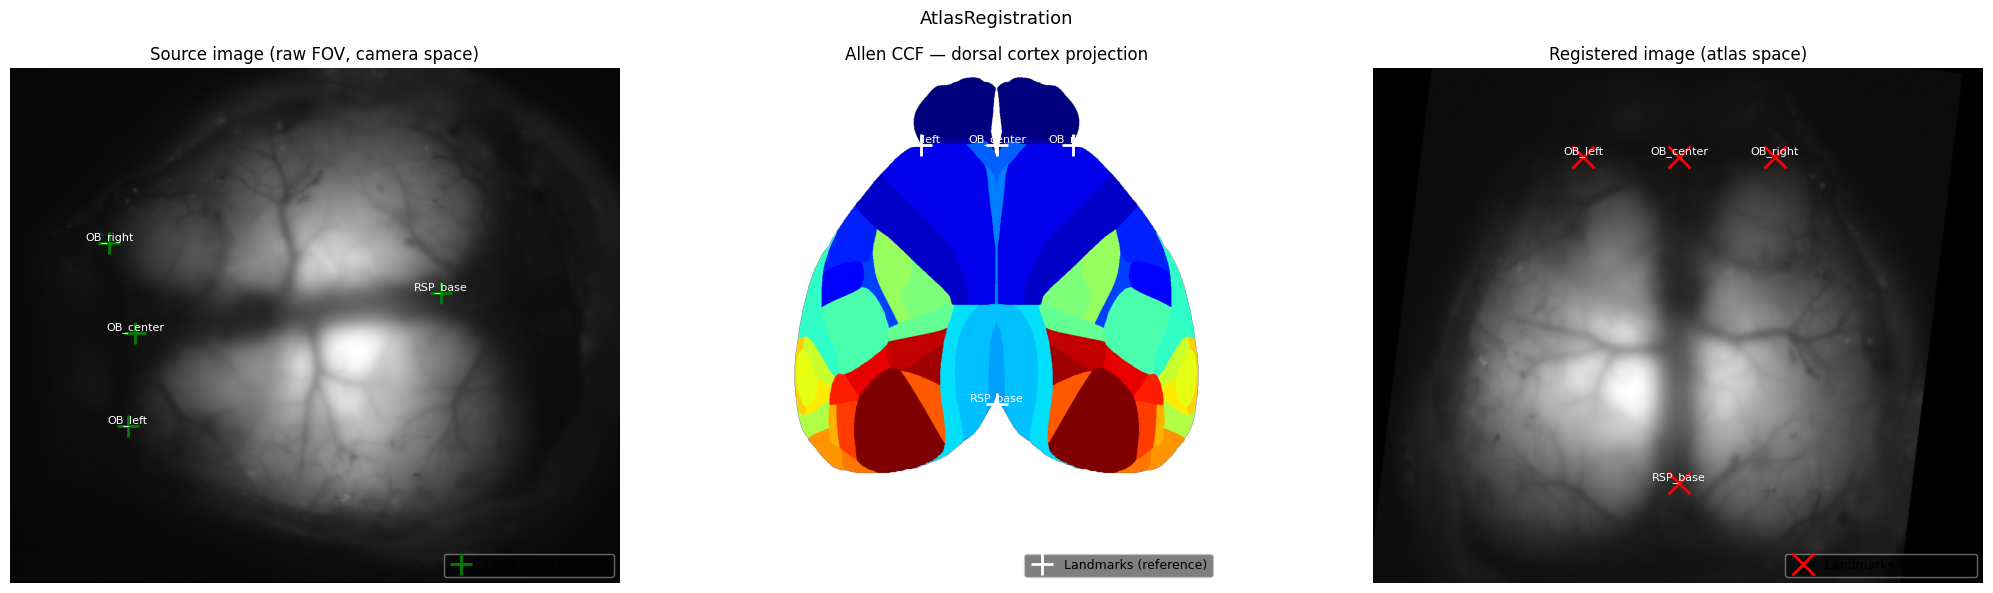

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=100)

# --- Source image ---
axes[0].imshow(source_img, cmap="gray")
axes[0].plot(
    landmarks_df["source_x"], landmarks_df["source_y"],
    "g+", ms=16, mew=2, label="Landmarks (source)",
)
for _, row in landmarks_df.iterrows():
    axes[0].text(
        row["source_x"], row["source_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[0].set_title("Source image (raw FOV, camera space)")
axes[0].axis("off")
axes[0].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

# --- Atlas projection ---
proj_masked = np.ma.masked_equal(atlas_proj, 0)
cmap_jet = plt.get_cmap("jet").copy()
cmap_jet.set_bad(alpha=0)
axes[1].imshow(proj_masked, cmap=cmap_jet)
axes[1].plot(
    landmarks_df["reference_x"], landmarks_df["reference_y"],
    "w+", ms=16, mew=2, label="Landmarks (reference)",
)
for _, row in landmarks_df.iterrows():
    axes[1].text(
        row["reference_x"], row["reference_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[1].set_title("Allen CCF — dorsal cortex projection")
axes[1].axis("off")
axes[1].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

# --- Registered image ---
axes[2].imshow(registered_img, cmap="gray")
axes[2].plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "rx", ms=16, mew=2, label="Landmarks (registered)",
)
for _, row in landmarks_df.iterrows():
    axes[2].text(
        row["registered_x"], row["registered_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[2].set_title("Registered image (atlas space)")
axes[2].axis("off")
axes[2].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

plt.suptitle("AtlasRegistration", fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Anatomical Coordinates Image <a id="aci"></a>

`AnatomicalCoordinatesImage` assigns a physical 3-D coordinate and a brain-region
label to every pixel in an image.  It lives under
`nwbfile.lab_meta_data["localization"].anatomical_coordinates_images`.

**IBL Bregma (RAS)**
| Name | Linked to | Description |
|---|---|---|
| `AnatomicalCoordinatesImageIBLBregma` | `GrayscaleImage` (`RegisteredImage`) | Registered-space per-pixel IBL bregma coordinates |

Coordinate system:

| Array | Shape | Description |
|---|---|---|
| `x` | `(H, W)` | Mediolateral (positive = Right) |
| `y` | `(H, W)` | Anteroposterior (positive = Anterior) |
| `z` | `(H, W)` | Dorsoventral (positive = Superior; ≈ 0 for 2-D FOV) |
| `brain_region` | `(H, W)` | Allen acronym string (`"out-of-atlas"` outside atlas) |

In [8]:
localization = nwbfile.lab_meta_data["localization"]
aci = localization.anatomical_coordinates_images["AnatomicalCoordinatesImageIBLBregma"]

space        = aci.space
x_coords     = aci.x[:]               # ML in µm
y_coords     = aci.y[:]               # AP in µm
region_names = np.asarray(aci.brain_region[:])
in_atlas     = region_names != "out-of-atlas"

print(f"Name          : {aci.name}")
print(f"Description   : {aci.description}")
print(f"Space         : {space.space_name}")
print(f"  Origin      : {space.origin}")
print(f"  Units       : {space.units}")
print(f"  Orientation : {space.orientation}  (x={space.orientation[0]}, y={space.orientation[1]}, z={space.orientation[2]})")
print(f"Image shape   : {aci.image.data[:].shape}")
print(f"ML (x) range  : [{x_coords[in_atlas].min():.0f}, {x_coords[in_atlas].max():.0f}] µm")
print(f"AP (y) range  : [{y_coords[in_atlas].min():.0f}, {y_coords[in_atlas].max():.0f}] µm")
print(f"Brain regions : {len(np.unique(region_names[in_atlas]))} unique Allen acronyms in atlas")

Name          : AnatomicalCoordinatesImageIBLBregma
Description   : Estimated coordinates for each pixel of the registered image in IBL bregma-centered coordinate system.
Space         : IBLBregma
  Origin      : bregma
  Units       : um
  Orientation : RAS  (x=R, y=A, z=S)
Image shape   : (540, 640)
ML (x) range  : [-5160, 5160] µm
AP (y) range  : [-5160, 4966] µm
Brain regions : 33 unique Allen acronyms in atlas


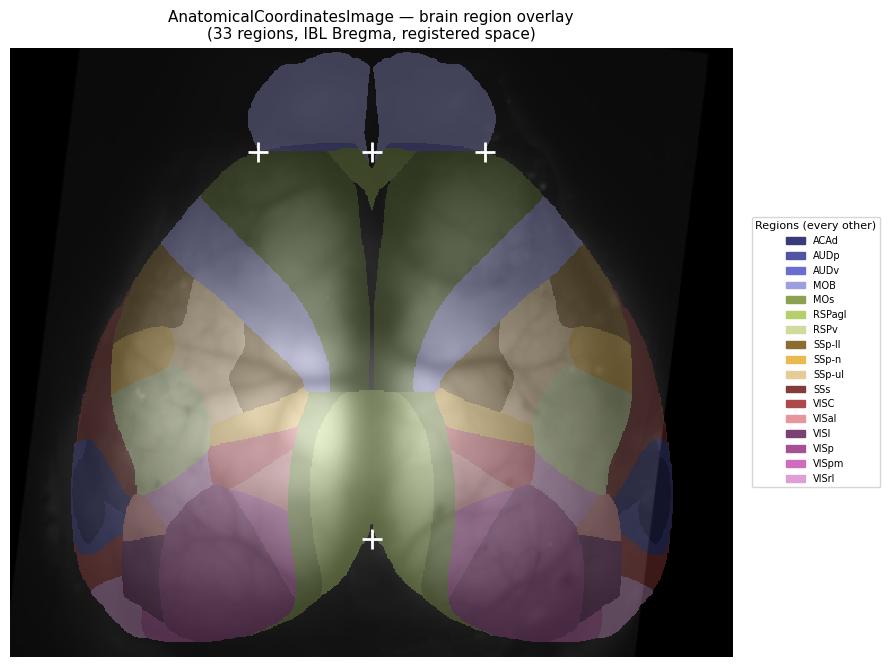

In [9]:
# Brain region overlay on the registered image
background   = "out-of-atlas"
names        = np.unique(region_names)
names        = names[names != background]
n            = len(names)
name_to_idx  = {name: i + 1 for i, name in enumerate(names)}

idx_img = np.zeros(region_names.shape, dtype=np.int16)
for name, i in name_to_idx.items():
    idx_img[region_names == name] = i
idx_masked = np.ma.masked_where(idx_img == 0, idx_img)

base_cmap   = plt.get_cmap("tab20b", max(n, 1))
colors      = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n))])
region_cmap = ListedColormap(colors)
region_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
ax.imshow(registered_img, cmap="gray")
ax.imshow(idx_masked, cmap=region_cmap, alpha=0.35, interpolation="nearest")
ax.plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "w+", ms=14, mew=2, label="Landmarks",
)
ax.set_title(
    f"AnatomicalCoordinatesImage — brain region overlay\n({n} regions, IBL Bregma, registered space)",
    fontsize=11,
)
ax.axis("off")

handles = [
    mpatches.Patch(color=region_cmap(name_to_idx[name]), label=name)
    for name in names[::2]  # every other region to keep legend readable
]
ax.legend(
    handles=handles,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, title="Regions (every other)",
    fontsize=7, title_fontsize=8,
)
plt.tight_layout()
plt.show()

**Allen CCF (PIR)**
| Name | Linked to | Description |
|---|---|---|
| `AnatomicalCoordinatesImageCCFv3` | `GrayscaleImage` (`RegisteredImage`) | Registered-space per-pixel Allen CCF coordinates |
| `AnatomicalCoordinatesCCFv3MappedOnSourceImage` | `GrayscaleImage` (`SourceImage`) | Source-space per-pixel Allen CCF coordinates |

Coordinate system:

| Array | Shape | Description |
|---|---|---|
| `x` | `(H, W)` | Anteroposterior (positive = Anterior)|
| `y` | `(H, W)` | Dorsoventral (positive = Superior) |
| `z` | `(H, W)` | Mediolateral (positive = Right) |
| `brain_region` | `(H, W)` | Allen acronym string (`"out-of-atlas"` outside atlas) |

In [10]:
localization = nwbfile.lab_meta_data["localization"]
aci = localization.anatomical_coordinates_images["AnatomicalCoordinatesImageCCFv3"]

space        = aci.space
x_coords     = aci.x[:]               # ML in µm
y_coords     = aci.y[:]               # AP in µm
region_names = np.asarray(aci.brain_region[:])
in_atlas     = region_names != "out-of-atlas"

print(f"Name          : {aci.name}")
print(f"Description   : {aci.description}")
print(f"Space         : {space.space_name}")
print(f"  Origin      : {space.origin}")
print(f"  Units       : {space.units}")
print(f"  Orientation : {space.orientation}  (x={space.orientation[0]}, y={space.orientation[1]}, z={space.orientation[2]})")
print(f"Image shape   : {aci.image.data[:].shape}")
print(f"ML (x) range  : [{x_coords[in_atlas].min():.0f}, {x_coords[in_atlas].max():.0f}] µm")
print(f"AP (y) range  : [{y_coords[in_atlas].min():.0f}, {y_coords[in_atlas].max():.0f}] µm")
print(f"Brain regions : {len(np.unique(region_names[in_atlas]))} unique Allen acronyms in atlas")


Name          : AnatomicalCoordinatesImageCCFv3
Description   : Estimated coordinates for each pixel of the registered image in CCFv3 coordinate system.
Space         : AllenCCFv3
  Origin      : Anterior-Superior-Left (ASL) corner of the 3D image volume
  Units       : um
  Orientation : PIR  (x=P, y=I, z=R)
Image shape   : (540, 640)
ML (x) range  : [240, 10366] µm
AP (y) range  : [332, 332] µm
Brain regions : 33 unique Allen acronyms in atlas


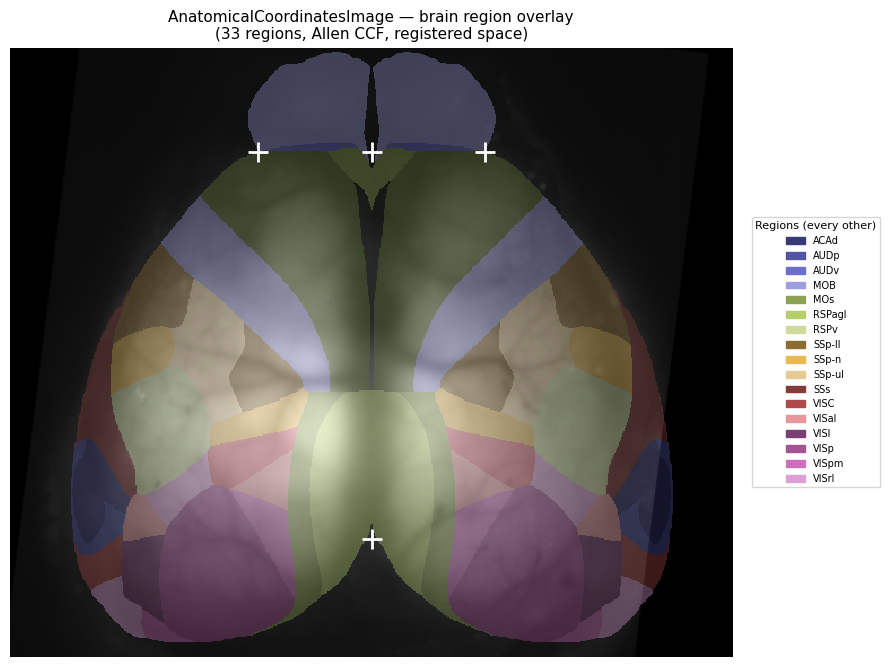

In [11]:
# Brain region overlay on the registered image
background   = "out-of-atlas"
names        = np.unique(region_names)
names        = names[names != background]
n            = len(names)
name_to_idx  = {name: i + 1 for i, name in enumerate(names)}

idx_img = np.zeros(region_names.shape, dtype=np.int16)
for name, i in name_to_idx.items():
    idx_img[region_names == name] = i
idx_masked = np.ma.masked_where(idx_img == 0, idx_img)

base_cmap   = plt.get_cmap("tab20b", max(n, 1))
colors      = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n))])
region_cmap = ListedColormap(colors)
region_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
ax.imshow(registered_img, cmap="gray")
ax.imshow(idx_masked, cmap=region_cmap, alpha=0.35, interpolation="nearest")
ax.plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "w+", ms=14, mew=2, label="Landmarks",
)
ax.set_title(
    f"AnatomicalCoordinatesImage — brain region overlay\n({n} regions, Allen CCF, registered space)",
    fontsize=11,
)
ax.axis("off")

handles = [
    mpatches.Patch(color=region_cmap(name_to_idx[name]), label=name)
    for name in names[::2]  # every other region to keep legend readable
]
ax.legend(
    handles=handles,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, title="Regions (every other)",
    fontsize=7, title_fontsize=8,
)
plt.tight_layout()
plt.show()

In [12]:
localization = nwbfile.lab_meta_data["localization"]
aci = localization.anatomical_coordinates_images["AnatomicalCoordinatesCCFv3MappedOnSourceImage"]

space = aci.space
x_coords = aci.x[:]  # ML in µm
y_coords = aci.y[:]  # AP in µm
region_names = np.asarray(aci.brain_region[:])
in_atlas = region_names != "out-of-atlas"

print(f"Name          : {aci.name}")
print(f"Description   : {aci.description}")
print(f"Space         : {space.space_name}")
print(f"  Origin      : {space.origin}")
print(f"  Units       : {space.units}")
print(
    f"  Orientation : {space.orientation}  (x={space.orientation[0]}, y={space.orientation[1]}, z={space.orientation[2]})"
)
print(f"Image shape   : {aci.image.data[:].shape}")
print(f"ML (x) range  : [{x_coords[in_atlas].min():.0f}, {x_coords[in_atlas].max():.0f}] µm")
print(f"AP (y) range  : [{y_coords[in_atlas].min():.0f}, {y_coords[in_atlas].max():.0f}] µm")
print(f"Brain regions : {len(np.unique(region_names[in_atlas]))} unique Allen acronyms in atlas")

Name          : AnatomicalCoordinatesCCFv3MappedOnSourceImage
Description   : Estimated coordinates for each pixel of the source image in CCFv3 coordinate system.
Space         : AllenCCFv3
  Origin      : Anterior-Superior-Left (ASL) corner of the 3D image volume
  Units       : um
  Orientation : PIR  (x=P, y=I, z=R)
Image shape   : (540, 640)
ML (x) range  : [240, 10366] µm
AP (y) range  : [332, 332] µm
Brain regions : 33 unique Allen acronyms in atlas


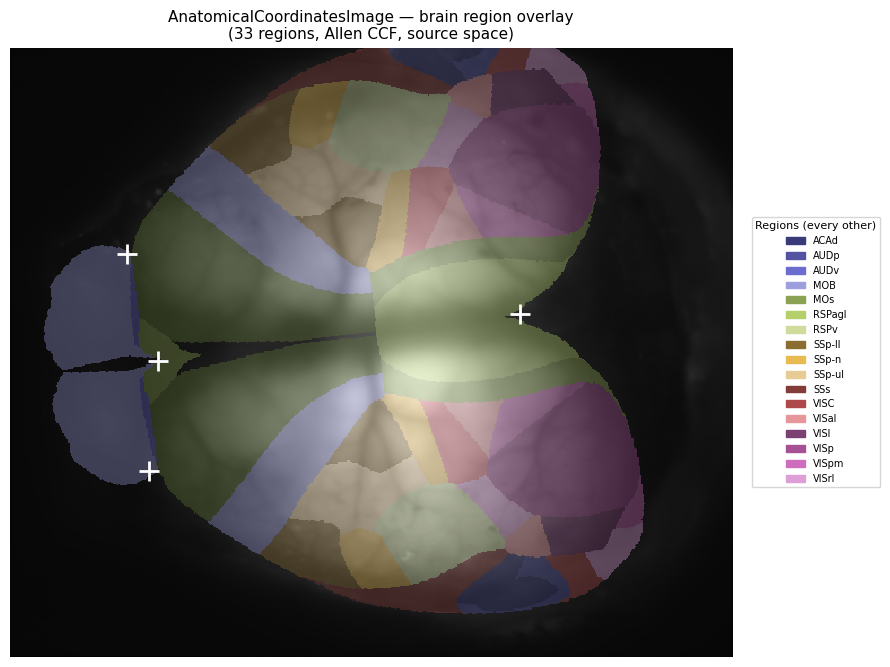

In [13]:
# Brain region overlay on the source image
background = "out-of-atlas"
names = np.unique(region_names)
names = names[names != background]
n = len(names)
name_to_idx = {name: i + 1 for i, name in enumerate(names)}

idx_img = np.zeros(region_names.shape, dtype=np.int16)
for name, i in name_to_idx.items():
    idx_img[region_names == name] = i
idx_masked = np.ma.masked_where(idx_img == 0, idx_img)

base_cmap = plt.get_cmap("tab20b", max(n, 1))
colors = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n))])
region_cmap = ListedColormap(colors)
region_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
ax.imshow(source_img, cmap="gray")
ax.imshow(idx_masked, cmap=region_cmap, alpha=0.35, interpolation="nearest")
ax.plot(
    landmarks_df["source_x"],
    landmarks_df["source_y"],
    "w+",
    ms=14,
    mew=2,
    label="Landmarks",
)
ax.set_title(
    f"AnatomicalCoordinatesImage — brain region overlay\n({n} regions, Allen CCF, source space)",
    fontsize=11,
)
ax.axis("off")

handles = [
    mpatches.Patch(color=region_cmap(name_to_idx[name]), label=name)
    for name in names[::2]  # every other region to keep legend readable
]
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Regions (every other)",
    fontsize=7,
    title_fontsize=8,
)
plt.tight_layout()
plt.show()

### CCFv3 coordinate sanity check <a id="ccf-sanity"></a>

The three cells below visualise the per-pixel CCFv3 coordinate fields and perform
a quick sanity check on the landmark positions.

**What to look for**

| Map | Expected pattern |
|---|---|
| AP heatmap | Smooth gradient — more-anterior (smaller x) at the top of the image, more-posterior (larger x) at the bottom |
| DV heatmap | Nearly uniform — all dorsal-cortex pixels sit at roughly the same depth (~332 µm from the superior face) |
| ML heatmap | Smooth symmetric gradient — left hemisphere (smaller z) on one side, right hemisphere (larger z) on the other |

**Landmark scatter (AP vs ML plane)**

| Landmark | Expected position |
|---|---|
| `OB_left`, `OB_right` | Symmetric about the midline (~5 700 µm ML), at the anterior pole (large x) |
| `OB_center` | On the midline, same AP as OB_left / OB_right |
| `RSP_base` | On the midline, at the posterior pole (small x, since CCF PIR x increases posterior) |

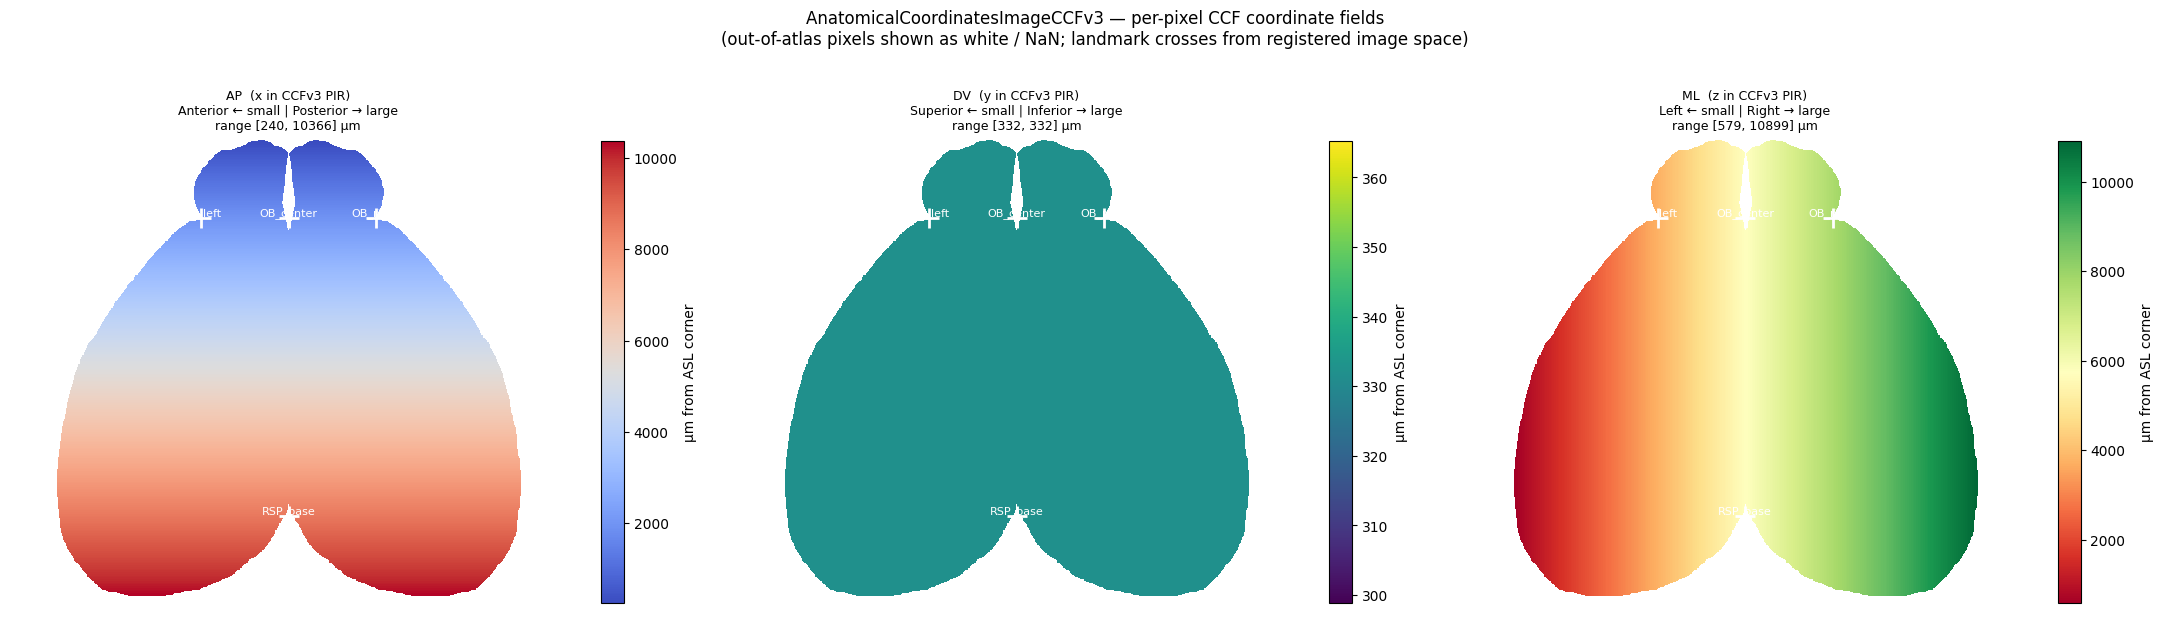

In [14]:
# CCFv3 PIR orientation:
#   x = Posterior (AP axis, increases anterior→posterior from ASL corner)
#   y = Inferior  (DV axis, increases superior→inferior)
#   z = Right     (ML axis, increases left→right)
#
# Sanity checks:
#   AP map  → should show a smooth anterior-to-posterior gradient top→bottom
#   DV map  → should be nearly uniform (~332 µm for dorsal-cortex surface)
#   ML map  → should show a symmetric left-to-right gradient

ccf_aci = localization.anatomical_coordinates_images["AnatomicalCoordinatesImageCCFv3"]
ap_img = ccf_aci.x[:]  # PIR x = AP (Posterior direction)
dv_img = ccf_aci.y[:]  # PIR y = DV (Inferior direction)
ml_img = ccf_aci.z[:]  # PIR z = ML (Right direction)
region_names_ccf = np.asarray(ccf_aci.brain_region[:])
in_atlas_ccf = region_names_ccf != "out-of-atlas"

ap_masked = np.where(in_atlas_ccf, ap_img, np.nan)
dv_masked = np.where(in_atlas_ccf, dv_img, np.nan)
ml_masked = np.where(in_atlas_ccf, ml_img, np.nan)

lm_df = landmarks[:]  # already loaded in the Atlas-Registration section


def _add_landmarks(ax, df):
    ax.plot(df["registered_x"], df["registered_y"], "w+", ms=14, mew=2, zorder=5)
    for _, row in df.iterrows():
        ax.text(
            row["registered_x"],
            row["registered_y"],
            row["landmark_labels"],
            color="white",
            fontsize=8,
            va="bottom",
            ha="center",
            zorder=6,
        )


fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- AP (x in PIR) ---
im0 = axes[0].imshow(ap_masked, cmap="coolwarm", interpolation="nearest")
_add_landmarks(axes[0], lm_df)
axes[0].set_title(
    f"AP  (x in CCFv3 PIR)\nAnterior ← small | Posterior → large\n"
    f"range [{np.nanmin(ap_masked):.0f}, {np.nanmax(ap_masked):.0f}] µm",
    fontsize=9,
)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="µm from ASL corner", shrink=0.75)

# --- DV (y in PIR) — expect near-constant for a dorsal projection ---
im1 = axes[1].imshow(dv_masked, cmap="viridis", interpolation="nearest")
_add_landmarks(axes[1], lm_df)
axes[1].set_title(
    f"DV  (y in CCFv3 PIR)\nSuperior ← small | Inferior → large\n"
    f"range [{np.nanmin(dv_masked):.0f}, {np.nanmax(dv_masked):.0f}] µm",
    fontsize=9,
)
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], label="µm from ASL corner", shrink=0.75)

# --- ML (z in PIR) ---
im2 = axes[2].imshow(ml_masked, cmap="RdYlGn", interpolation="nearest")
_add_landmarks(axes[2], lm_df)
axes[2].set_title(
    f"ML  (z in CCFv3 PIR)\nLeft ← small | Right → large\n"
    f"range [{np.nanmin(ml_masked):.0f}, {np.nanmax(ml_masked):.0f}] µm",
    fontsize=9,
)
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], label="µm from ASL corner", shrink=0.75)

plt.suptitle(
    "AnatomicalCoordinatesImageCCFv3 — per-pixel CCF coordinate fields\n"
    "(out-of-atlas pixels shown as white / NaN; landmark crosses from registered image space)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

CCF landmark coordinates (PIR orientation, µm from ASL corner):
  Landmark           AP (x) µm     DV (y) µm     ML (z) µm
  -----------------------------------------------------
  OB_left               1950.0         332.0        3789.0
  OB_center             1950.0         332.0        5739.0
  OB_right              1950.0         332.0        7689.0
  RSP_base              8600.0         332.0        5739.0

AP ordering (smaller x = more anterior in CCF PIR):
  OB_center AP = 1950 µm,  RSP_base AP = 8600 µm


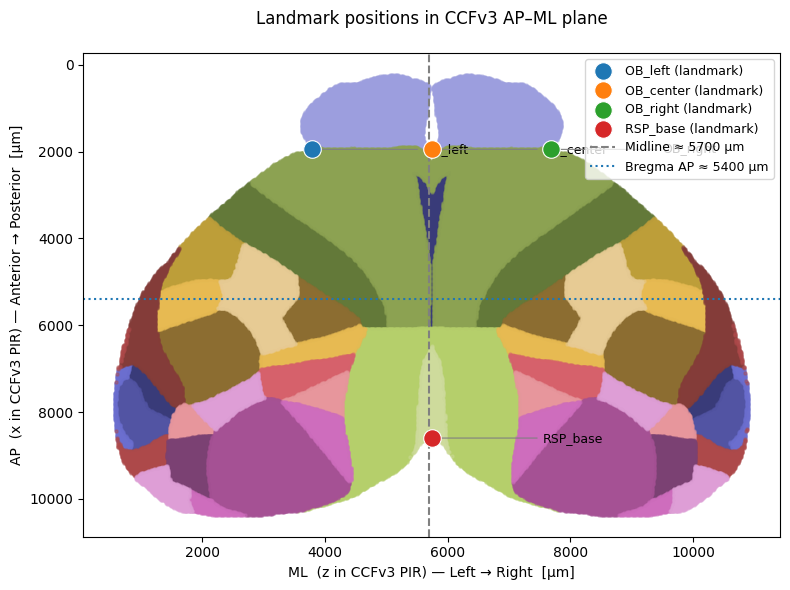

In [15]:

# Landmark positions in the CCF AP–ML plane
# Expected anatomy:
#   - OB (olfactory bulb) is at the anterior pole of the dorsal cortex
#   - RSP (retrosplenial cortex) is near the posterior pole
#   - OB_left and OB_right should be symmetric about the midline
#   - OB_center and RSP_base should lie on the midline (ML ≈ 5700 µm in CCFv3)
#
# In CCFv3 PIR the AP axis runs: 0 µm (anterior face) → ~13 200 µm (posterior face)
# so SMALLER x values are more ANTERIOR.

ccf_lm = localization.anatomical_coordinates_tables["AnatomicalCoordinatesCCFv3"][:]

print("CCF landmark coordinates (PIR orientation, µm from ASL corner):")
print(f"  {'Landmark':15s} {'AP (x) µm':>12s}  {'DV (y) µm':>12s}  {'ML (z) µm':>12s}")
print("  " + "-" * 53)
for _, row in ccf_lm.iterrows():
    print(f"  {row['brain_region']:15s} {row['x']:12.1f}  {row['y']:12.1f}  {row['z']:12.1f}")

# Derived sanity metrics
ob_left_ml = ccf_lm.loc[ccf_lm["brain_region"] == "OB_left", "z"].values[0]
ob_right_ml = ccf_lm.loc[ccf_lm["brain_region"] == "OB_right", "z"].values[0]
ob_center_ml = ccf_lm.loc[ccf_lm["brain_region"] == "OB_center", "z"].values[0]
ob_center_ap = ccf_lm.loc[ccf_lm["brain_region"] == "OB_center", "x"].values[0]
rsp_ml = ccf_lm.loc[ccf_lm["brain_region"] == "RSP_base", "z"].values[0]
rsp_ap = ccf_lm.loc[ccf_lm["brain_region"] == "RSP_base", "x"].values[0]

midline_est = (ob_left_ml + ob_right_ml) / 2
CCF_MIDLINE_UM = 5700  # approximate midline in Allen CCFv3
CCF_BREGMA_AP_UM = 5400  # approximate bregma AP position in CCFv3

print()
print("AP ordering (smaller x = more anterior in CCF PIR):")
ob_is_anterior = ob_center_ap > rsp_ap  # in CCF, larger x = more posterior
print(f"  OB_center AP = {ob_center_ap:.0f} µm,  RSP_base AP = {rsp_ap:.0f} µm")

# ── Build per-region colormap ─────────────────────────────────────────────────
unique_regions_ccf = np.unique(region_names_ccf[in_atlas_ccf])
n_regions = len(unique_regions_ccf)
region_palette = plt.get_cmap("tab20b")(np.linspace(0, 1, n_regions))
region_color_map = {r: region_palette[i] for i, r in enumerate(unique_regions_ccf)}

# ── Scatter plot: AP vs ML ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# One scatter call per region so each gets a legend entry
for region in unique_regions_ccf:
    mask = region_names_ccf == region
    ax.scatter(
        ml_img[mask],
        ap_img[mask],
        s=5,
        color=region_color_map[region],
        alpha=0.4,
        label=region,
        rasterized=True,
    )

# Landmark markers on top
colors = plt.get_cmap("tab10")(range(len(ccf_lm)))
for i, (_, row) in enumerate(ccf_lm.iterrows()):
    ax.scatter(
        row["z"],
        row["x"],
        s=160,
        color=colors[i],
        zorder=4,
        edgecolors="white",
        linewidths=0.8,
        label=f"{row['brain_region']} (landmark)",
    )
    ax.annotate(
        row["brain_region"],
        xy=(row["z"], row["x"]),
        xytext=(80, 0),
        textcoords="offset points",
        fontsize=9,
        va="center",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    )

ax.axvline(CCF_MIDLINE_UM, color="gray", ls="--", lw=1.5, label=f"Midline ≈ {CCF_MIDLINE_UM} µm")
ax.axhline(CCF_BREGMA_AP_UM, color="tab:blue", ls=":", lw=1.5, label=f"Bregma AP ≈ {CCF_BREGMA_AP_UM} µm")

ax.set_xlabel("ML  (z in CCFv3 PIR) — Left → Right  [µm]")
ax.set_ylabel("AP  (x in CCFv3 PIR) — Anterior → Posterior  [µm]")
ax.set_title("Landmark positions in CCFv3 AP–ML plane\n")
ax.invert_yaxis()  # small AP (anterior) at top

# Split legend: region pixels on the left panel, landmarks/lines on the right
region_handles = [mpatches.Patch(color=region_color_map[r], label=r) for r in unique_regions_ccf]
landmark_handles, landmark_labels = [], []
for h, l in zip(*ax.get_legend_handles_labels()):
    if l not in unique_regions_ccf:
        landmark_handles.append(h)
        landmark_labels.append(l)

legend1 = ax.legend(
    handles=region_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=7,
    title="Brain regions",
    title_fontsize=8,
    frameon=True,
)
ax.add_artist(legend1)
ax.legend(
    landmark_handles,
    landmark_labels,
    loc="upper right",
    fontsize=9,
)

plt.tight_layout()
plt.show()


---

## 4. Anatomical Coordinates Tables <a id="act"></a>

`AnatomicalCoordinatesTable` stores 3-D anatomical coordinates for discrete
objects (the registration landmarks here).  Each row gives `(x, y, z)` in a
named `Space` and a back-reference (`localized_entity`) to the `Landmarks` table.

Two tables are stored per session under `localization.anatomical_coordinates_tables`:

| Name | Space | Orientation | Description |
|---|---|---|---|
| `AnatomicalCoordinatesIBLBregma` | IBL Bregma | RAS | x=ML, y=AP, z=DV; bregma=origin; µm |
| `AnatomicalCoordinatesCCFv3` | Allen CCFv3 | PIR | x=AP, y=DV, z=ML; ASL corner=origin; µm |

In [16]:
ibl_table = localization.anatomical_coordinates_tables["AnatomicalCoordinatesIBLBregma"]

print(f"Space      : {ibl_table.space.space_name}")
print(f"  Origin   : {ibl_table.space.origin}")
print(f"  Orient.  : {ibl_table.space.orientation}")
print(f"  Units    : {ibl_table.space.units}")
print(f"Method     : {ibl_table.method}")
print()
ibl_table[:]

Space      : IBLBregma
  Origin   : bregma
  Orient.  : RAS
  Units    : um
Method     : IBL bregma-centered coordinates (um, RAS: x=ML, y=AP, z=DV) of anatomical landmarks read directly from widefieldLandmarks.dorsalCortex.json, where they are stored as bregma-relative positions in mm.



,x,y,z,localized_entity,brain_region
id,,,,,
0,-1950.0,-3450.0,0.0,0,OB_left
1,0.0,-3450.0,0.0,1,OB_center
2,1950.0,-3450.0,0.0,2,OB_right
3,0.0,3200.0,0.0,3,RSP_base


In [17]:
ccf_table = localization.anatomical_coordinates_tables["AnatomicalCoordinatesCCFv3"]

print(f"Space      : {ccf_table.space.space_name}")
print(f"  Origin   : {ccf_table.space.origin}")
print(f"  Orient.  : {ccf_table.space.orientation}")
print(f"  Units    : {ccf_table.space.units}")
print(f"Method     : {ccf_table.method}")
print()
ccf_table[:]

Space      : AllenCCFv3
  Origin   : Anterior-Superior-Left (ASL) corner of the 3D image volume
  Orient.  : PIR
  Units    : um
Method     : Allen CCF v3 coordinates (um, PIR+: x=AP, y=DV, z=ML) of anatomical landmarks derived by converting IBL bregma-relative landmark positions (mm, from widefieldLandmarks.dorsalCortex.json) to Allen CCF v3 via iblatlas.AllenAtlas.xyz2ccf.



,x,y,z,localized_entity,brain_region
id,,,,,
0,1950.0,332.0,3789.0,0,OB_left
1,1950.0,332.0,5739.0,1,OB_center
2,1950.0,332.0,7689.0,2,OB_right
3,8600.0,332.0,5739.0,3,RSP_base
